Domaine : Genitourinary / Reproductive

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix,
    jaccard_score
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb

In [4]:
df = pd.read_csv("Diseases_and_Symptoms_dataset.csv")

disease_col = "diseases"
symptom_cols = [c for c in df.columns if c != disease_col]

In [5]:
gu_diseases = [
    'vaginitis', 'vulvodynia', 'acute kidney injury',
    'vaginal cyst', 'benign prostatic hyperplasia (BPH)',
    'idiopathic excessive menstruation',
    'temporary or benign blood in urine',
    'idiopathic irregular menstrual cycle',
    'idiopathic painful menstruation',
    'urinary tract infection',
    'pelvic inflammatory disease',
    'cystitis',
    'spontaneous abortion',
    'threatened pregnancy'
]

df_gu = df[df[disease_col].isin(gu_diseases)].copy()
print("GU dataset shape:", df_gu.shape)


GU dataset shape: (12185, 231)



Top 10 most frequent symptoms:
sharp abdominal pain                    5837
lower abdominal pain                    5341
pelvic pain                             4516
cramps and spasms                       3609
vaginal discharge                       3356
painful urination                       2996
intermenstrual bleeding                 2873
back pain                               2862
heavy menstrual flow                    2498
blood clots during menstrual periods    2410
dtype: int64


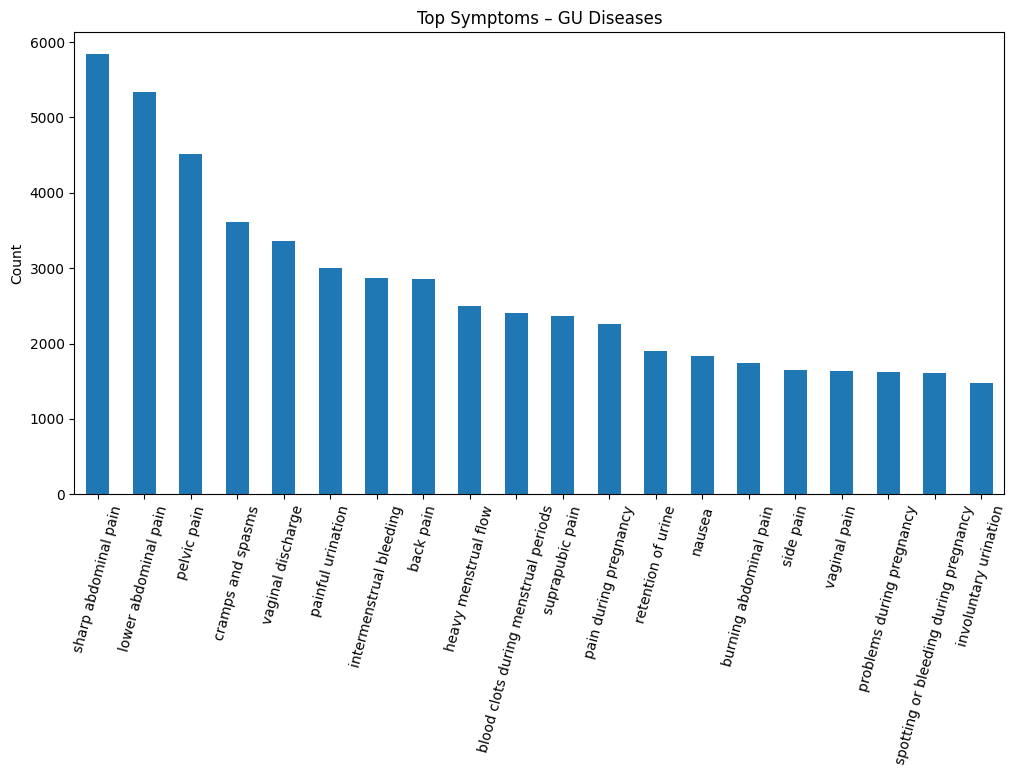

In [6]:
symptom_counts = df_gu[symptom_cols].sum().sort_values(ascending=False)

print("\nTop 10 most frequent symptoms:")
print(symptom_counts.head(10))

top_symptoms = symptom_counts.head(20).index.tolist()

plt.figure(figsize=(12,6))
symptom_counts.head(20).plot(kind="bar")
plt.title("Top Symptoms – GU Diseases")
plt.ylabel("Count")
plt.xticks(rotation=75)
plt.show()

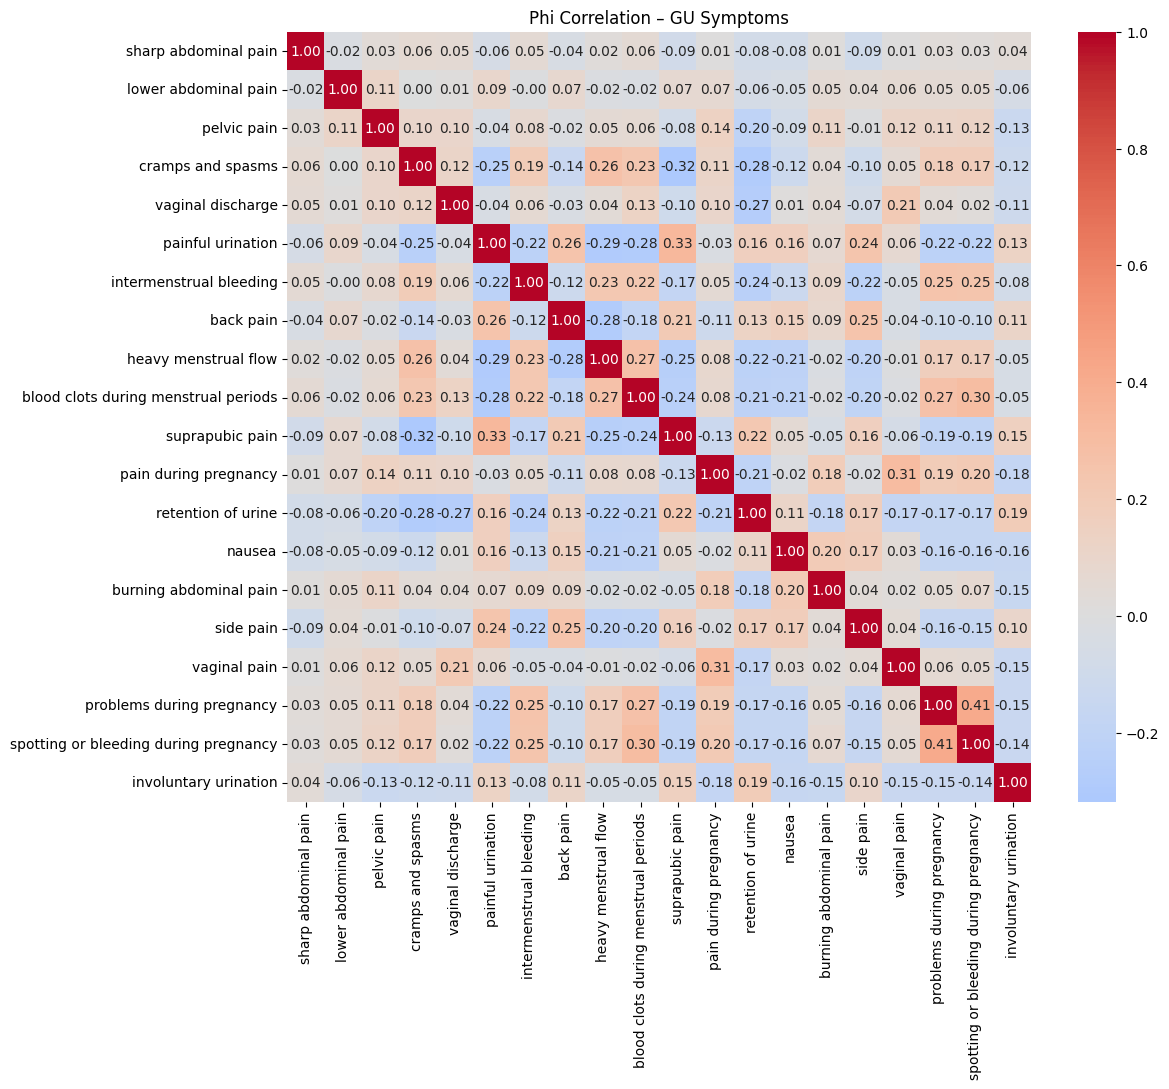

In [7]:
# Phi correlation (binary Pearson)
plt.figure(figsize=(12,10))
sns.heatmap(
    df_gu[top_symptoms].corr(),
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)
plt.title("Phi Correlation – GU Symptoms")
plt.show()

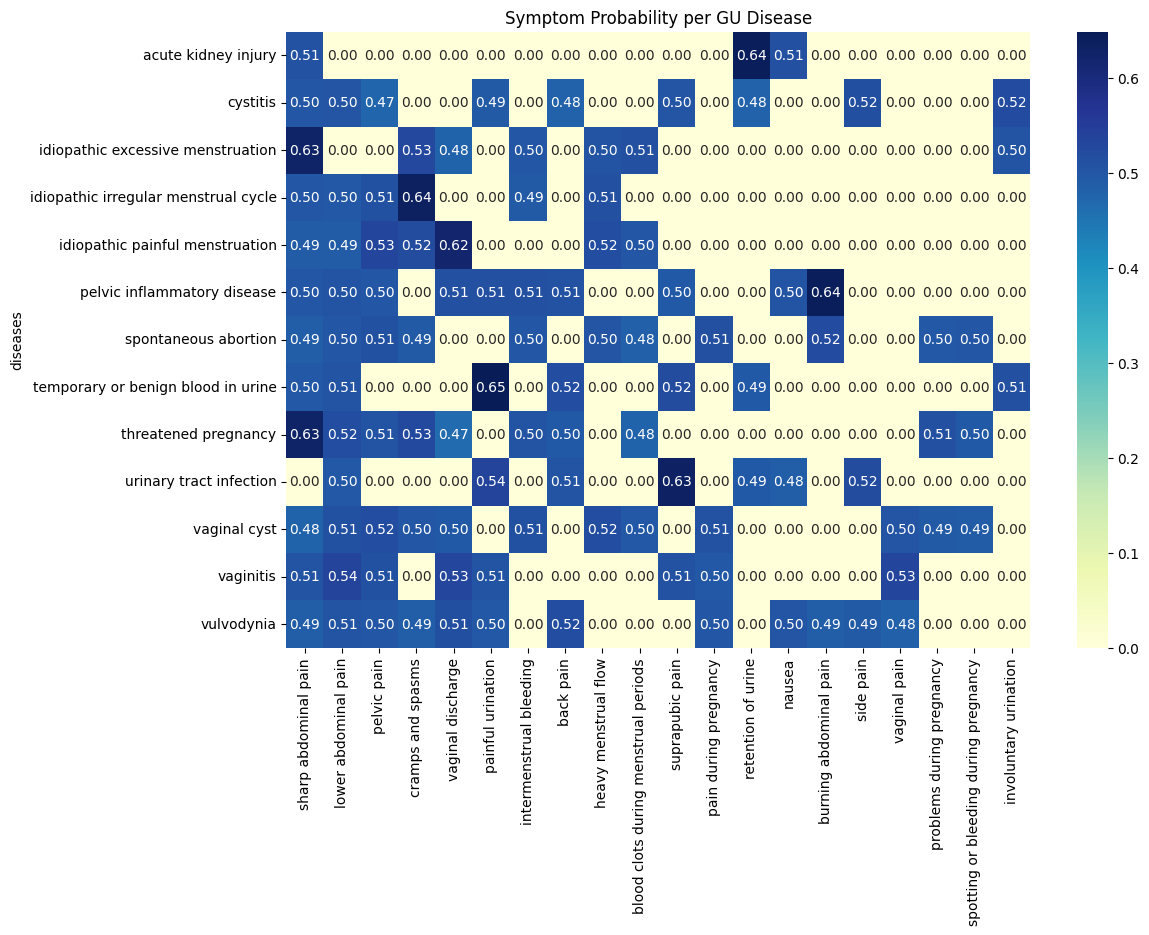

In [8]:
# Disease–Symptom probability
disease_symptom_prob = df_gu.groupby(disease_col)[symptom_cols].mean()

plt.figure(figsize=(12,8))
sns.heatmap(
    disease_symptom_prob[top_symptoms],
    cmap="YlGnBu",
    annot=True,
    fmt=".2f"
)
plt.title("Symptom Probability per GU Disease")
plt.show()

In [9]:
# Feature selection & encoding
selected_symptoms = symptom_counts[symptom_counts > 0].index.tolist()

X = df_gu[selected_symptoms]
y = df_gu[disease_col]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


In [10]:
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42
    ),

    "XGBoost": xgb.XGBClassifier(
        n_estimators=500,
        learning_rate=0.3,
        random_state=42,
        eval_metric="mlogloss"
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        multi_class="ovr"
    )
}


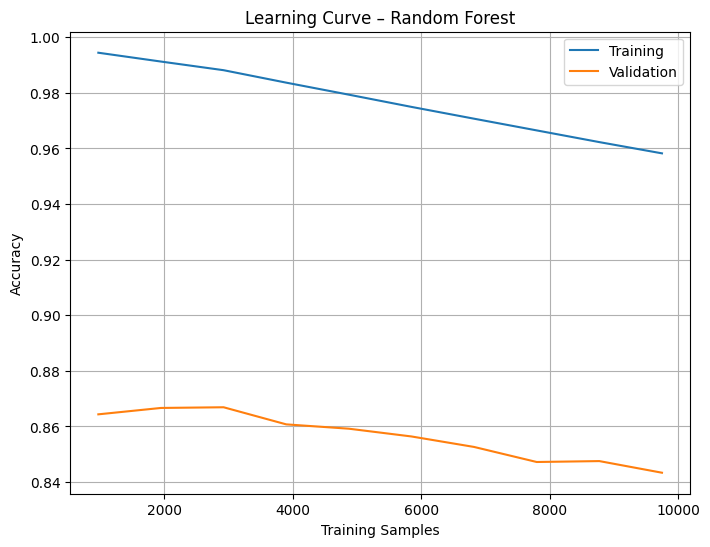

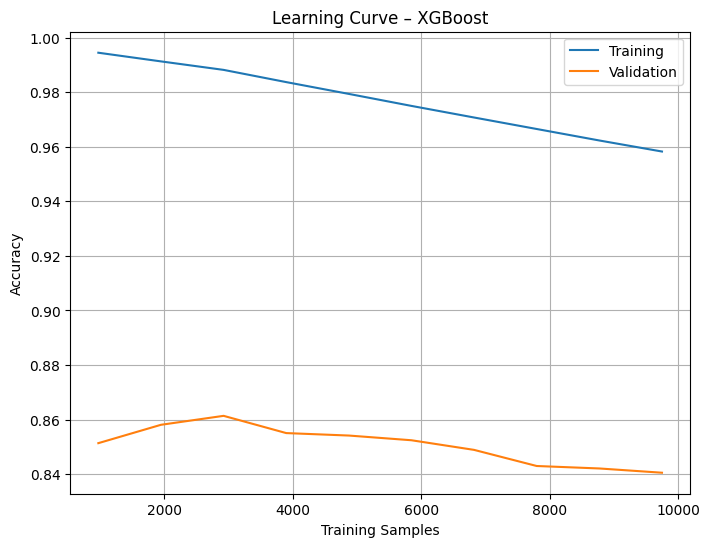

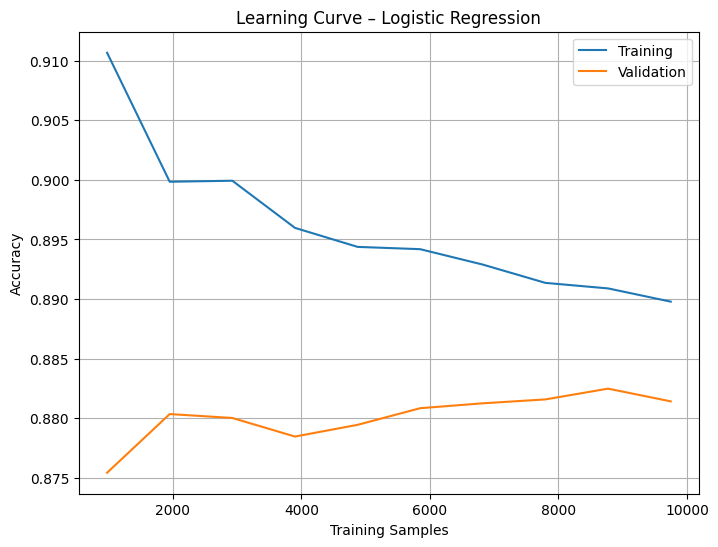

In [11]:
# Learning curves
def plot_learning_curve(model, X, y, name):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=5,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring="accuracy",
        n_jobs=-1,
        shuffle=True,
        random_state=42
    )

    plt.figure(figsize=(8,6))
    plt.plot(train_sizes, train_scores.mean(axis=1), label="Training")
    plt.plot(train_sizes, val_scores.mean(axis=1), label="Validation")
    plt.title(f"Learning Curve – {name}")
    plt.xlabel("Training Samples")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid()
    plt.show()


for name, model in models.items():
    plot_learning_curve(model, X, y_encoded, name)

In [12]:
# Train & evaluate models
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))




Training Random Forest...
Random Forest Accuracy: 0.8416
                                      precision    recall  f1-score   support

                 acute kidney injury       1.00      0.99      0.99       162
                            cystitis       0.78      0.79      0.79       244
   idiopathic excessive menstruation       0.85      0.82      0.83       166
idiopathic irregular menstrual cycle       0.86      0.90      0.88       163
     idiopathic painful menstruation       0.80      0.85      0.82       161
         pelvic inflammatory disease       0.89      0.93      0.91       161
                spontaneous abortion       0.85      0.75      0.80       242
  temporary or benign blood in urine       0.71      0.69      0.70       160
                threatened pregnancy       0.74      0.76      0.75       164
             urinary tract infection       0.90      0.93      0.91       163
                        vaginal cyst       0.76      0.78      0.77       243
     

c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1273: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Accuracy: 0.8740
                                      precision    recall  f1-score   support

                 acute kidney injury       1.00      0.99      0.99       162
                            cystitis       0.89      0.77      0.82       244
   idiopathic excessive menstruation       0.89      0.86      0.87       166
idiopathic irregular menstrual cycle       0.86      0.92      0.89       163
     idiopathic painful menstruation       0.83      0.90      0.87       161
         pelvic inflammatory disease       0.88      0.96      0.92       161
                spontaneous abortion       0.94      0.74      0.82       242
  temporary or benign blood in urine       0.71      0.82      0.76       160
                threatened pregnancy       0.73      0.90      0.81       164
             urinary tract infection       0.91      0.96      0.94       163
                        vaginal cyst       0.82      0.81      0.82       243
                          

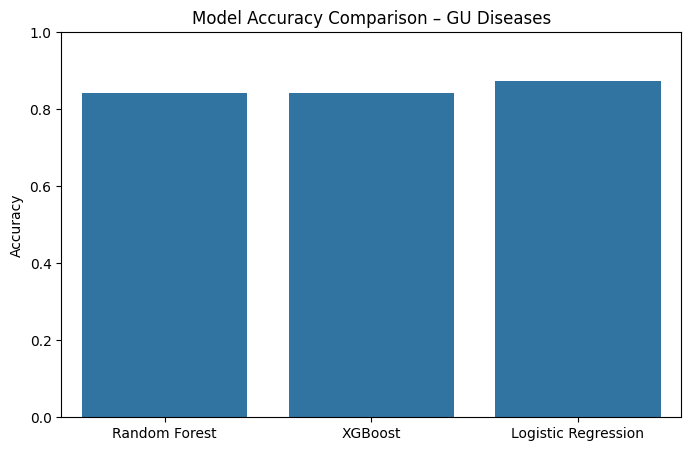

In [13]:
# Accuracy comparison
plt.figure(figsize=(8,5))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.title("Model Accuracy Comparison – GU Diseases")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

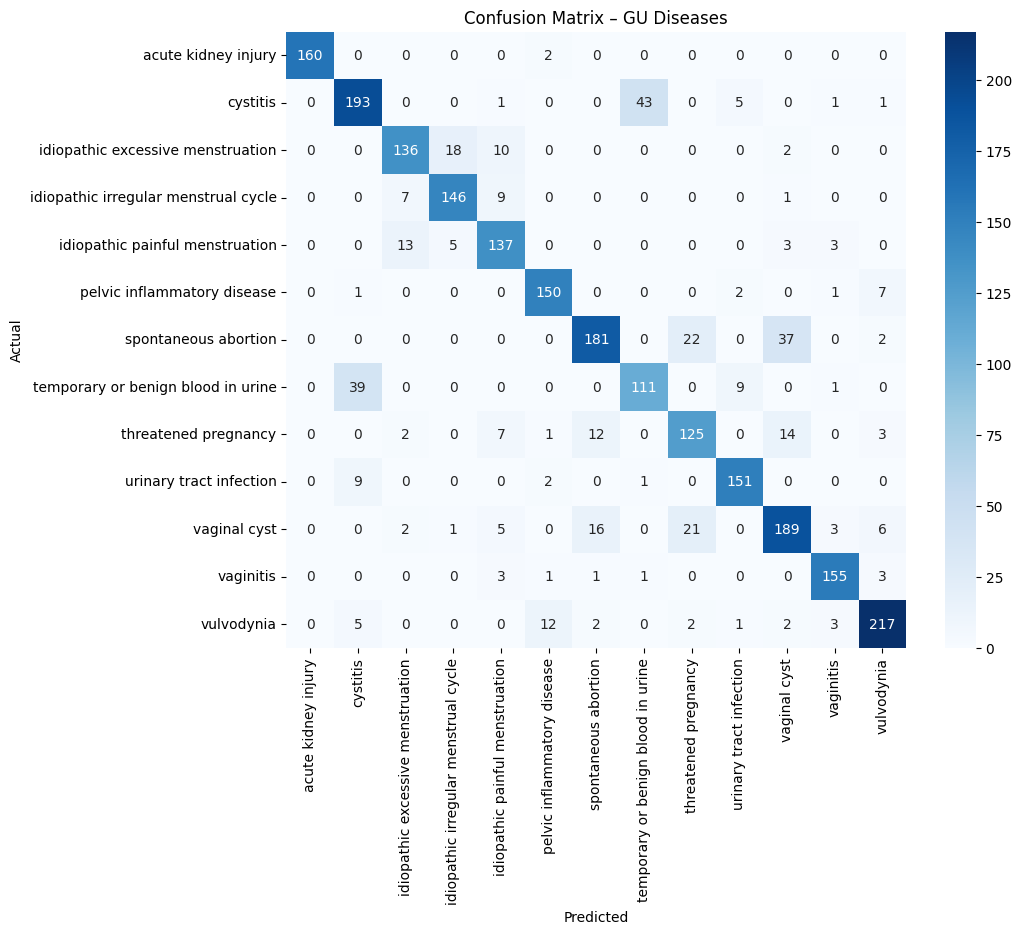

In [14]:
# Confusion matrix 
best_model = models["Random Forest"]
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – GU Diseases")
plt.show()


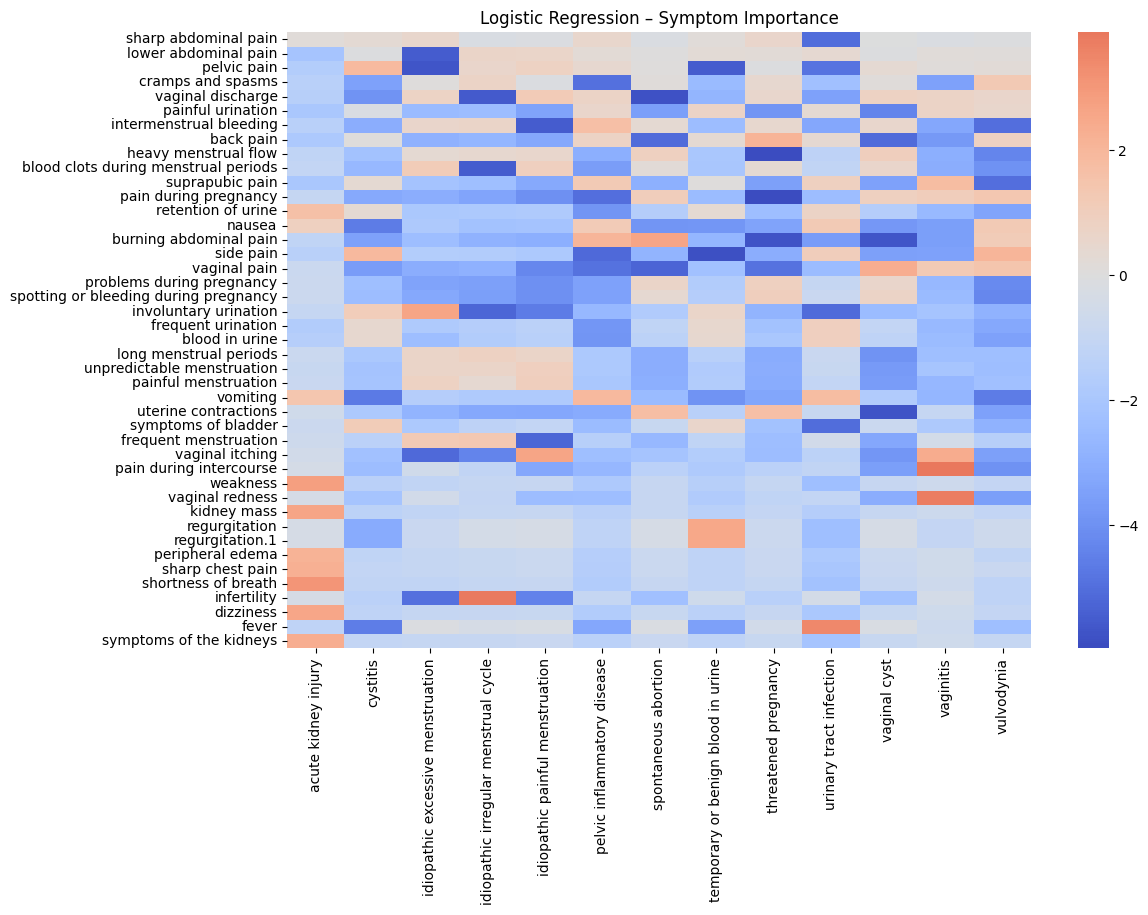

In [15]:
#  Logistic Regression feature importance
lr = models["Logistic Regression"]

coef_df = pd.DataFrame(
    lr.coef_.T,
    index=selected_symptoms,
    columns=le.classes_
)

plt.figure(figsize=(12,8))
sns.heatmap(coef_df, cmap="coolwarm", center=0)
plt.title("Logistic Regression – Symptom Importance")
plt.show()
